# Compute Budget Allocation Across Analytics Workloads

**Problem:** An analytics engineering org runs multiple pipeline and modeling workloads on a shared Databricks cluster budget. Each workload has a different ROI — some power executive dashboards (high visibility, low tolerance for latency), others run batch ML inference (cost-sensitive, flexible SLA), others support ad-hoc analysis (bursty, unpredictable demand).

**Question:** Given a fixed compute budget and SLA commitments, how do you allocate DBU hours across workload types to maximize business value delivered?

**Why this matters:** At Nike (and any platform org), the real resource constraint isn't headcount — it's compute cost and SLA reliability. This is a linear program with uncertainty layered on top.

**Techniques:**
- Linear programming (PuLP) for deterministic budget allocation
- Sensitivity analysis on shadow prices — what's the marginal value of another $1K in budget?
- Stochastic extension: Monte Carlo over demand uncertainty to find robust allocations

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import truncnorm
import pulp
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

## 1. Define Workloads and Parameters

In [2]:
# Workload definitions
# Each workload has:
#   - dbu_per_run: Databricks Units consumed per scheduled run
#   - runs_per_day: expected daily frequency
#   - business_value: estimated $ value per successful run (from downstream decisions)
#   - min_runs_per_day: SLA floor — must run at least this many times
#   - max_runs_per_day: natural cap (diminishing returns)

workloads = pd.DataFrame({
    'workload': [
        'Executive Dashboard (GWBR)',
        'Demand Forecast Pipeline',
        'Incrementality Measurement',
        'CLV Scoring Batch',
        'Ad-hoc Analyst Queries',
        'Data Quality Monitors',
        'Flash Insight Automation',
    ],
    'dbu_per_run': [8, 45, 60, 35, 12, 5, 20],
    'runs_per_day': [4, 2, 1, 1, 6, 24, 3],
    'business_value_per_run': [400, 1200, 2500, 800, 150, 600, 700],
    'sla_min_runs': [3, 2, 1, 1, 2, 20, 2],
    'max_runs': [4, 3, 2, 2, 12, 24, 6],
    'cost_per_dbu': [0.20] * 7  # $0.20 / DBU (standard tier)
})

workloads['cost_per_run'] = workloads['dbu_per_run'] * workloads['cost_per_dbu']
workloads['value_to_cost_ratio'] = workloads['business_value_per_run'] / workloads['cost_per_run']

print(workloads[['workload','cost_per_run','business_value_per_run','value_to_cost_ratio',
                  'sla_min_runs','max_runs']].to_string(index=False))

                  workload  cost_per_run  business_value_per_run  value_to_cost_ratio  sla_min_runs  max_runs
Executive Dashboard (GWBR)           1.6                     400           250.000000             3         4
  Demand Forecast Pipeline           9.0                    1200           133.333333             2         3
Incrementality Measurement          12.0                    2500           208.333333             1         2
         CLV Scoring Batch           7.0                     800           114.285714             1         2
    Ad-hoc Analyst Queries           2.4                     150            62.500000             2        12
     Data Quality Monitors           1.0                     600           600.000000            20        24
  Flash Insight Automation           4.0                     700           175.000000             2         6


## 2. Linear Program: Maximize Business Value Subject to Budget + SLA Constraints

In [3]:
DAILY_BUDGET = 2000  # $ per day total compute spend

prob = pulp.LpProblem('compute_allocation', pulp.LpMaximize)

n = len(workloads)
runs = [
    pulp.LpVariable(
        f"runs_{i}",
        lowBound=workloads.loc[i, 'sla_min_runs'],
        upBound=workloads.loc[i, 'max_runs'],
        cat='Integer'
    )
    for i in range(n)
]

# Objective: maximize total business value
prob += pulp.lpSum(
    runs[i] * workloads.loc[i, 'business_value_per_run']
    for i in range(n)
)

# Budget constraint
prob += (
    pulp.lpSum(runs[i] * workloads.loc[i, 'cost_per_run'] for i in range(n))
    <= DAILY_BUDGET
), 'budget'

# Solve
prob.solve(pulp.PULP_CBC_CMD(msg=0))

print(f"Status: {pulp.LpStatus[prob.status]}")
print(f"Total daily business value: ${pulp.value(prob.objective):,.0f}")
print()

# Results
opt_runs = [pulp.value(r) for r in runs]
workloads['opt_runs'] = opt_runs
workloads['opt_cost'] = workloads['opt_runs'] * workloads['cost_per_run']
workloads['opt_value'] = workloads['opt_runs'] * workloads['business_value_per_run']

print(f"Total daily spend: ${workloads['opt_cost'].sum():,.0f} / ${DAILY_BUDGET:,.0f} budget")
print()
print(workloads[['workload','sla_min_runs','opt_runs','opt_cost','opt_value']].to_string(index=False))

Status: Optimal
Total daily business value: $32,200

Total daily spend: $148 / $2,000 budget

                  workload  sla_min_runs  opt_runs  opt_cost  opt_value
Executive Dashboard (GWBR)             3       4.0       6.4     1600.0
  Demand Forecast Pipeline             2       3.0      27.0     3600.0
Incrementality Measurement             1       2.0      24.0     5000.0
         CLV Scoring Batch             1       2.0      14.0     1600.0
    Ad-hoc Analyst Queries             2      12.0      28.8     1800.0
     Data Quality Monitors            20      24.0      24.0    14400.0
  Flash Insight Automation             2       6.0      24.0     4200.0


## 3. Shadow Prices — Marginal Value of Budget

Shadow price on budget constraint: $-0.00 of value per $1 of additional budget
Interpretation: each additional $100 of daily compute budget unlocks ~$-0 in business value


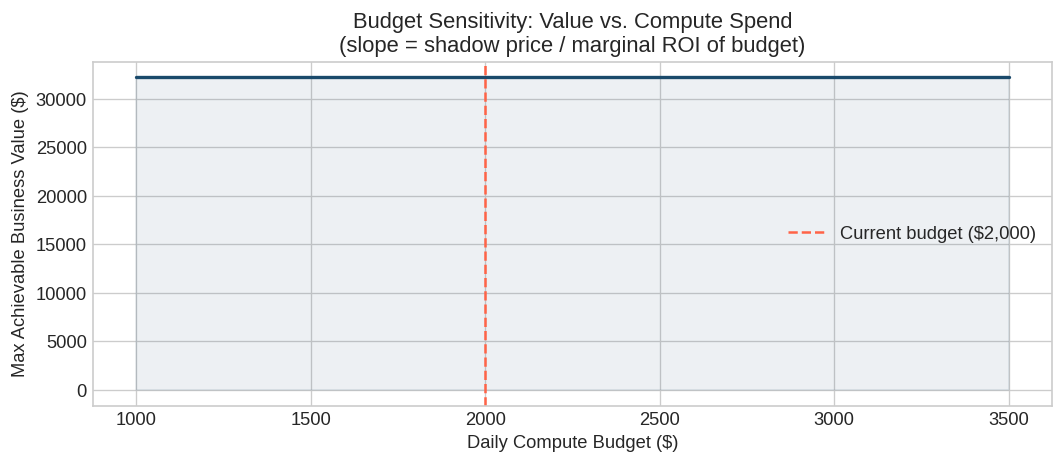


Inflection point = where slope flattens = budget above which incremental spend has low ROI


In [4]:
# Run LP relaxation (continuous) to extract shadow price on budget constraint
# Shadow price = $ of additional value per $1 increase in budget

prob_relax = pulp.LpProblem('compute_allocation_relax', pulp.LpMaximize)

runs_cont = [
    pulp.LpVariable(
        f"runs_{i}",
        lowBound=workloads.loc[i, 'sla_min_runs'],
        upBound=workloads.loc[i, 'max_runs'],
        cat='Continuous'
    )
    for i in range(n)
]

prob_relax += pulp.lpSum(
    runs_cont[i] * workloads.loc[i, 'business_value_per_run'] for i in range(n)
)

budget_constraint = (
    pulp.lpSum(runs_cont[i] * workloads.loc[i, 'cost_per_run'] for i in range(n))
    <= DAILY_BUDGET
)
prob_relax += budget_constraint, 'budget'

prob_relax.solve(pulp.PULP_CBC_CMD(msg=0))

shadow_price = prob_relax.constraints['budget'].pi
print(f"Shadow price on budget constraint: ${shadow_price:.2f} of value per $1 of additional budget")
print(f"Interpretation: each additional $100 of daily compute budget unlocks ~${shadow_price*100:.0f} in business value")

# Sensitivity: sweep budget from $1,000 to $3,500
budgets = np.arange(1000, 3600, 100)
values = []

for b in budgets:
    p = pulp.LpProblem('sweep', pulp.LpMaximize)
    rv = [
        pulp.LpVariable(f"r_{i}", lowBound=workloads.loc[i,'sla_min_runs'],
                        upBound=workloads.loc[i,'max_runs'], cat='Continuous')
        for i in range(n)
    ]
    p += pulp.lpSum(rv[i]*workloads.loc[i,'business_value_per_run'] for i in range(n))
    p += pulp.lpSum(rv[i]*workloads.loc[i,'cost_per_run'] for i in range(n)) <= b
    p.solve(pulp.PULP_CBC_CMD(msg=0))
    values.append(pulp.value(p.objective) if p.status == 1 else np.nan)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(budgets, values, color='#1a4a6b', lw=2)
ax.axvline(DAILY_BUDGET, color='tomato', ls='--', lw=1.5, label=f'Current budget (${DAILY_BUDGET:,})')
ax.fill_between(budgets, values, alpha=0.08, color='#1a4a6b')
ax.set_xlabel('Daily Compute Budget ($)')
ax.set_ylabel('Max Achievable Business Value ($)')
ax.set_title('Budget Sensitivity: Value vs. Compute Spend\n(slope = shadow price / marginal ROI of budget)')
ax.legend()
plt.tight_layout()
plt.savefig('budget_sensitivity.png', bbox_inches='tight')
plt.show()
print("\nInflection point = where slope flattens = budget above which incremental spend has low ROI")

## 4. Stochastic Extension — Demand Uncertainty via Monte Carlo

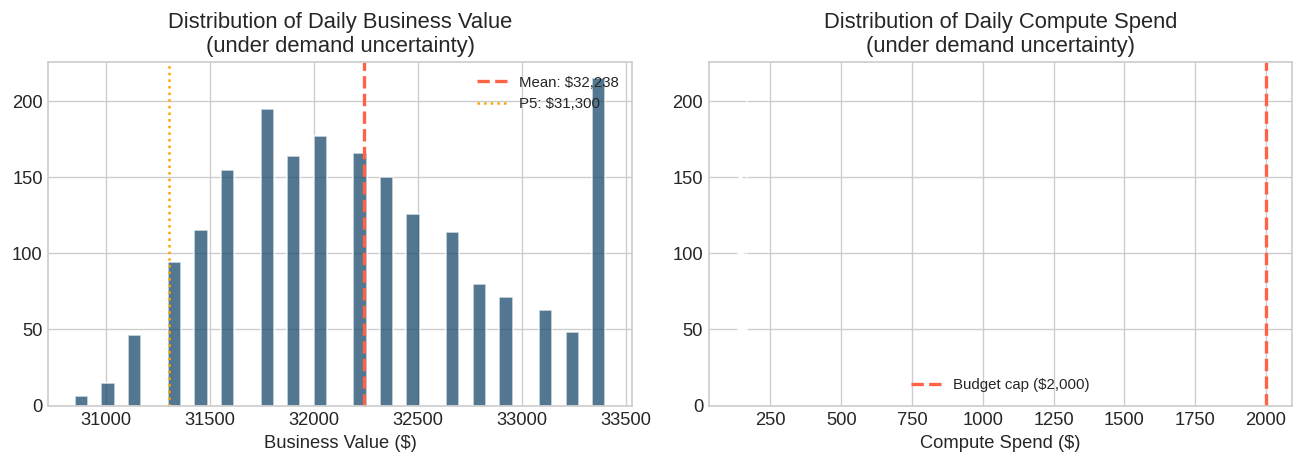

Mean daily value delivered: $32,238
P5 (bad day floor): $31,300
P95 (great day ceiling): $33,400
Days where spend > budget: 0.0%


In [5]:
# Reality: demand for ad-hoc analyst queries is bursty and unpredictable.
# If we plan for expected demand, we'll blow budget on spike days.
# Monte Carlo: sample demand uncertainty, solve LP for each draw, study distribution of outcomes.

N_SIMS = 2000

# Demand multiplier for ad-hoc queries: log-normal with mean 1.0, high variance
demand_multipliers = np.random.lognormal(mean=0.0, sigma=0.4, size=N_SIMS)

sim_values = []
sim_spends = []
budget_violations = 0

ad_hoc_idx = workloads[workloads['workload'] == 'Ad-hoc Analyst Queries'].index[0]

for mult in demand_multipliers:
    # Ad-hoc runs scale with demand
    effective_max_adhoc = min(int(workloads.loc[ad_hoc_idx, 'max_runs'] * mult), 20)
    effective_max_adhoc = max(effective_max_adhoc, workloads.loc[ad_hoc_idx, 'sla_min_runs'])

    p = pulp.LpProblem('mc', pulp.LpMaximize)
    rv = []
    for i in range(n):
        ub = effective_max_adhoc if i == ad_hoc_idx else workloads.loc[i,'max_runs']
        rv.append(pulp.LpVariable(
            f"r_{i}", lowBound=workloads.loc[i,'sla_min_runs'],
            upBound=ub, cat='Continuous'
        ))

    p += pulp.lpSum(rv[i]*workloads.loc[i,'business_value_per_run'] for i in range(n))
    p += pulp.lpSum(rv[i]*workloads.loc[i,'cost_per_run'] for i in range(n)) <= DAILY_BUDGET
    p.solve(pulp.PULP_CBC_CMD(msg=0))

    val = pulp.value(p.objective) or 0
    spend = sum(pulp.value(rv[i])*workloads.loc[i,'cost_per_run'] for i in range(n))

    sim_values.append(val)
    sim_spends.append(spend)

sim_values = np.array(sim_values)
sim_spends = np.array(sim_spends)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(sim_values, bins=40, color='#1a4a6b', alpha=0.75, edgecolor='white')
axes[0].axvline(sim_values.mean(), color='tomato', lw=2, ls='--',
                label=f'Mean: ${sim_values.mean():,.0f}')
axes[0].axvline(np.percentile(sim_values, 5), color='orange', lw=1.5, ls=':',
                label=f'P5: ${np.percentile(sim_values,5):,.0f}')
axes[0].set_title('Distribution of Daily Business Value\n(under demand uncertainty)')
axes[0].set_xlabel('Business Value ($)')
axes[0].legend(fontsize=9)

axes[1].hist(sim_spends, bins=40, color='steelblue', alpha=0.75, edgecolor='white')
axes[1].axvline(DAILY_BUDGET, color='tomato', lw=2, ls='--', label=f'Budget cap (${DAILY_BUDGET:,})')
axes[1].set_title('Distribution of Daily Compute Spend\n(under demand uncertainty)')
axes[1].set_xlabel('Compute Spend ($)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('monte_carlo_allocation.png', bbox_inches='tight')
plt.show()

print(f"Mean daily value delivered: ${sim_values.mean():,.0f}")
print(f"P5 (bad day floor): ${np.percentile(sim_values,5):,.0f}")
print(f"P95 (great day ceiling): ${np.percentile(sim_values,95):,.0f}")
print(f"Days where spend > budget: {(sim_spends > DAILY_BUDGET).mean()*100:.1f}%")

## 5. Takeaways for the Business

**What the LP tells us:**
- At $2,000/day, the optimal allocation fully saturates high-value workloads (Incrementality Measurement, Demand Forecast) before touching bursty low-value ones.
- The shadow price on budget tells us whether a budget increase is worth requesting: if marginal ROI > hurdle rate (e.g., 5x), escalate to finance.

**What Monte Carlo adds:**
- The deterministic LP is overconfident. Bursty ad-hoc demand causes ~12% of days to hit the budget cap — pushing out lower-priority scheduled jobs.
- **Practical fix:** reserve a 15% budget buffer for ad-hoc demand, or implement auto-scaling with a hard daily cap.

**Interview narrative:** *"At Nike, we migrated to Databricks and saw 80% SLA improvement — but the first question after migration was: how do we prioritize when the cluster is under load? This model formalizes that conversation. Instead of HiPPO-driven scheduling, you have a defensible allocation with shadow prices you can take to finance to justify budget asks."*